# Probability Distributions

**Goal:** Understand discrete and continuous distributions, especially Bernoulli, Binomial, and Gaussian.

**Reference:** Mathematics for ML - Chapter 6.3, 6.4, 6.5, 6.6

## Discrete vs Continuous

**Discrete random variable** — takes countable values
- PMF (probability mass function): $p(x) = P(X = x)$
- $\sum_x p(x) = 1$

**Continuous random variable** — takes values in an interval
- PDF (probability density function): $p(x)$
- $\int_{-\infty}^{\infty} p(x) \, dx = 1$
- $P(a \leq X \leq b) = \int_a^b p(x) \, dx$

In [17]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats

## Bernoulli Distribution

A single trial with two outcomes: success (1) or failure (0).

$$P(X = 1) = p, \quad P(X = 0) = 1 - p$$

- **Mean:** $p$
- **Variance:** $p(1-p)$

**Example:** coin flip, whether a user clicks an ad.

In [18]:
p = 0.3
samples = np.random.binomial(1,p, size=10_000)

print(f"Empirical mean: {samples.mean():.4f}, theoretical: {p}")
print(f"Empirical var:  {samples.var():.4f}, theoretical: {p*(1-p):.4f}")

Empirical mean: 0.3003, theoretical: 0.3
Empirical var:  0.2101, theoretical: 0.2100


## Binomial Distribution

Number of successes in $n$ independent Bernoulli trials with probability $p$.

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

- **Mean:** $np$
- **Variance:** $np(1-p)$

**Example:** number of heads in 10 coin flips.

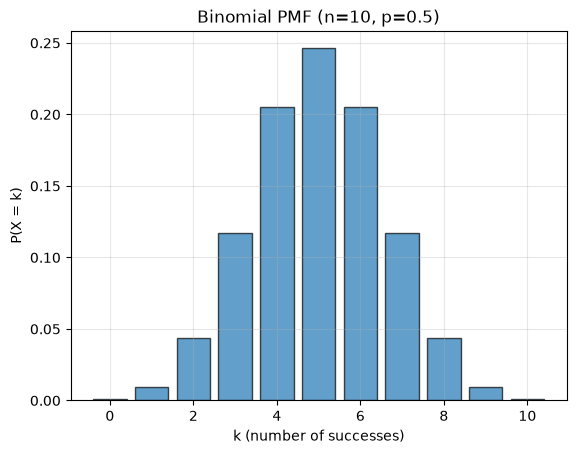

Empirical mean: 4.9916, theoretical: 5.0
Empirical var:  2.4947, theoretical: 2.5000


In [19]:
n, p = 10, 0.5
x = np.arange(0, n + 1)
pmf = stats.binom.pmf(x, n, p)

plt.bar(x, pmf, alpha=0.7, edgecolor='black')
plt.xlabel('k (number of successes)')
plt.ylabel('P(X = k)')
plt.title(f'Binomial PMF (n={n}, p={p})')
plt.grid(True, alpha=0.3)
plt.show()

samples = np.random.binomial(n, p, size=10_000)
print(f"Empirical mean: {samples.mean():.4f}, theoretical: {n*p}")
print(f"Empirical var:  {samples.var():.4f}, theoretical: {n*p*(1-p):.4f}")

## Gaussian (Normal) Distribution

The most important distribution in ML.

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$$

- **Mean:** $\mu$
- **Variance:** $\sigma^2$
- **Notation:** $X \sim \mathcal{N}(\mu, \sigma^2)$

**Why it matters:**
- Central Limit Theorem: sums of many independent variables → Gaussian
- Noise in linear regression is usually assumed Gaussian
- VAEs, diffusion models use Gaussian latent spaces
- Weight initialization in neural nets uses Gaussian

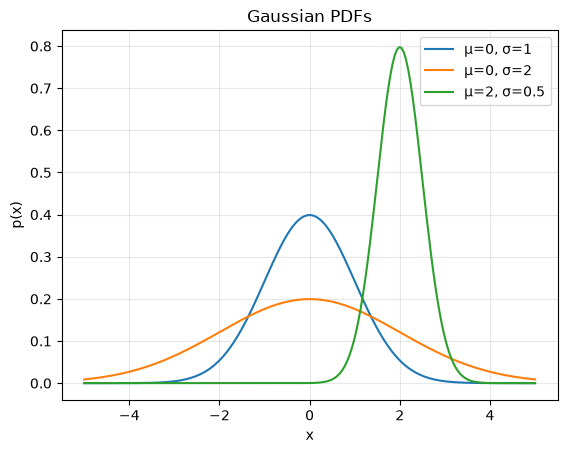

P(|X| < 1σ) = 0.6831
P(|X| < 2σ) = 0.9547
P(|X| < 3σ) = 0.9972


In [20]:
x = np.linspace(-5, 5, 200)

for mu, sigma in [(0, 1), (0, 2), (2, 0.5)]:
    pdf = stats.norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, label=f'μ={mu}, σ={sigma}')

plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('Gaussian PDFs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


samples = np.random.randn(100_000)
for k in [1, 2, 3]:
    within = np.mean(np.abs(samples) < k)
    print(f"P(|X| < {k}σ) = {within:.4f}")

## Multivariate Gaussian

For a vector $\mathbf{x} \in \mathbb{R}^d$:

$$p(\mathbf{x}) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu})\right)$$

- $\boldsymbol{\mu}$: mean vector
- $\Sigma$: covariance matrix (symmetric, positive definite)

**Intuition:** $\Sigma$ controls the shape and orientation of the "bell".

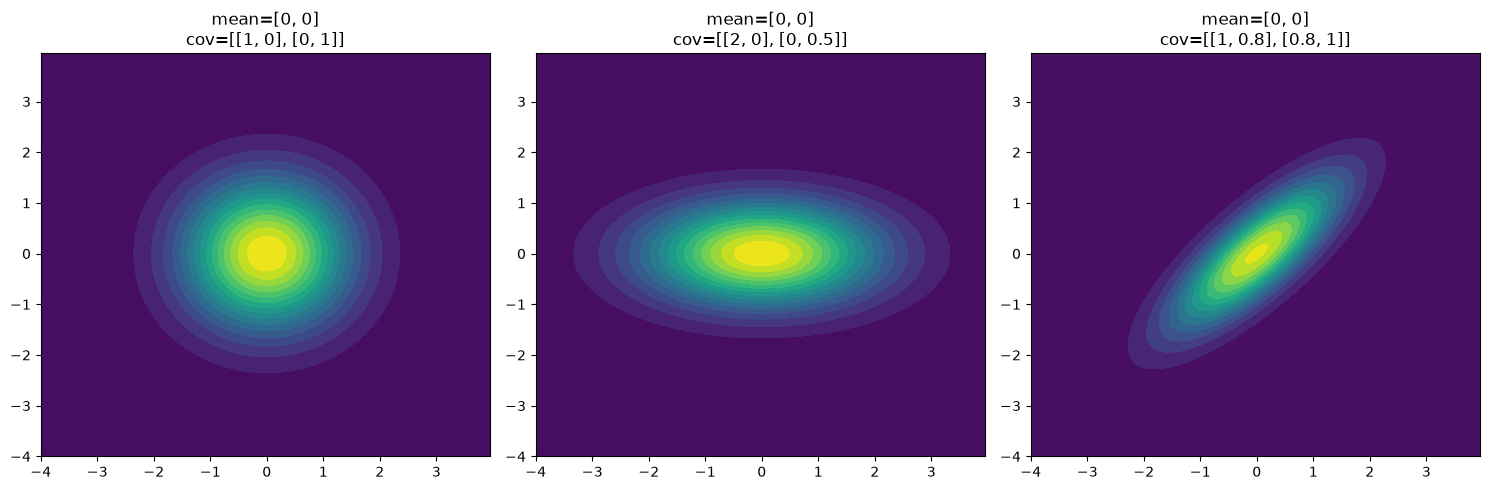

In [25]:
def plot_mvn(mean, cov, ax):
    x, y = np.mgrid[-4:4:.05, -4:4:.05]
    pos = np.dstack((x, y))
    rv = stats.multivariate_normal(mean, cov)
    # ax.contour(x, y, rv.pdf(pos), levels=15, cmap='viridis')
    ax.contourf(x, y, rv.pdf(pos), levels=15, cmap='viridis')
    ax.set_title(f'mean={mean}\ncov={cov}')


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_mvn([0, 0], [[1, 0], [0, 1]], axes[0])           # isotropic
plot_mvn([0, 0], [[2, 0], [0, 0.5]], axes[1])         # axis-aligned
plot_mvn([0, 0], [[1, 0.8], [0.8, 1]], axes[2])       # correlated
plt.tight_layout()
plt.show()

## Key Takeaways

- **Bernoulli:** single binary trial, mean $p$
- **Binomial:** count of successes in $n$ trials, mean $np$
- **Gaussian:** the universal distribution, defined by $\mu, \sigma^2$
- **Multivariate Gaussian:** vector version, defined by $\boldsymbol{\mu}, \Sigma$
- **68-95-99.7 rule:** how data spreads around the mean
- **Covariance structure:** diagonal = independent, off-diagonal = correlated

## Connection to ML

- Binary classification → Bernoulli
- Count data → Poisson, Binomial
- Continuous features → Gaussian
- Generative models → multivariate Gaussian latent space
- Noise assumptions in regression → Gaussian
